✔ Base classes found in: darkgreybox.models
✔ TiTmCn2R2C_summer_V9 injected into darkgreybox.models
  ⚠ Stubbing missing class: __main__.MockResult
✔ Pickle loaded successfully
  Keys: ['df', 'X_train', 'y_train', 'X_test', 'y_test', 'model', 'train_results', 'test_results', 'flat_samples', 'full_chain', 'theta_map', 'acceptance_fraction', 'autocorr_tau', 'param_names', 'bounds', 'sigma_obs']


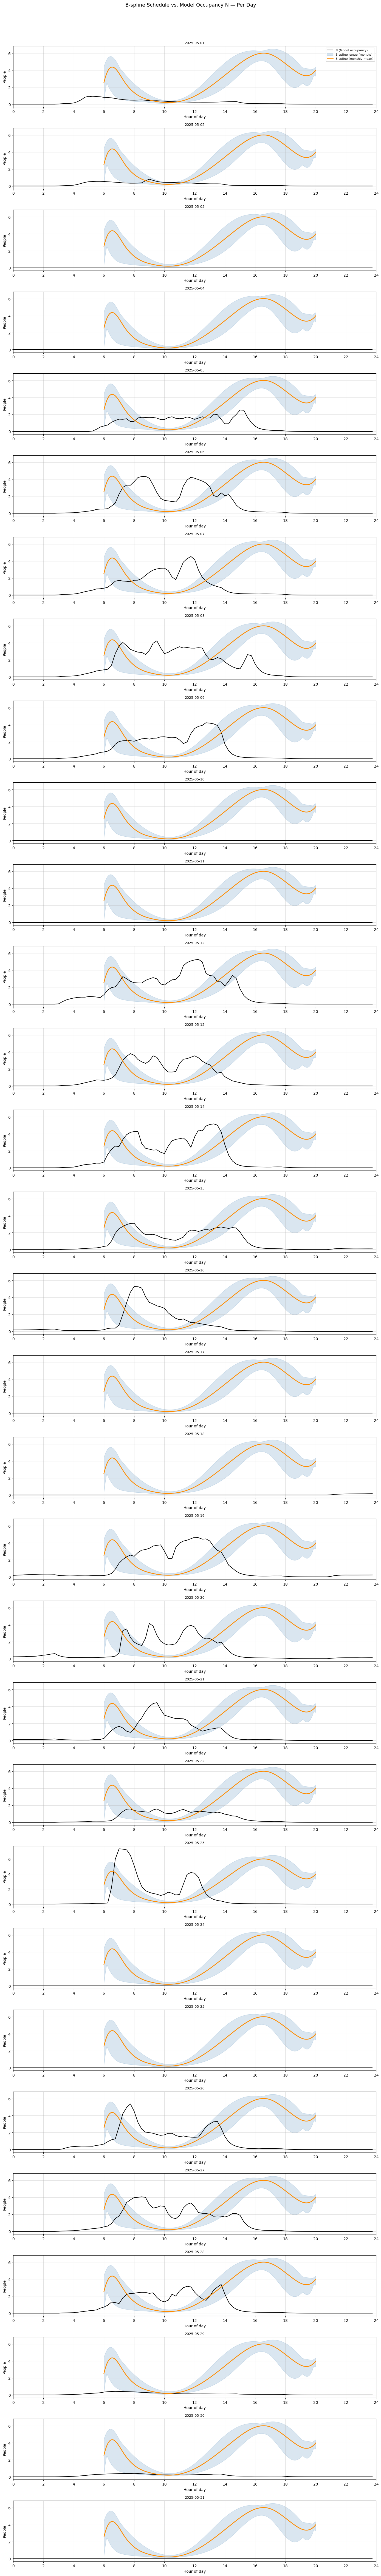

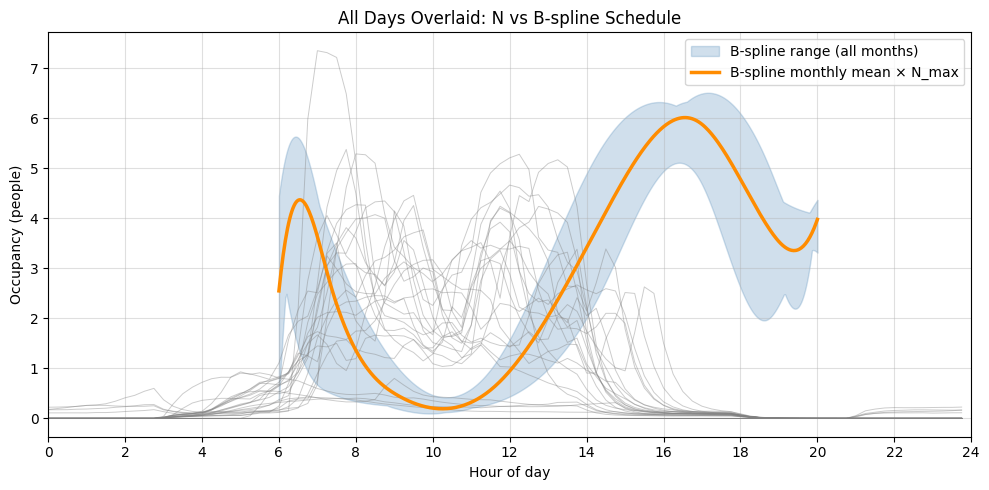

In [6]:
import pickle
import types
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pvlib
import importlib
import pkgutil
from scipy.interpolate import BSpline

# ── 0a. Universal stub for any unknown class ──────────────────────────────────
class _Stub:
    """Absorbs any pickle'd class whose definition is no longer available."""
    def __init__(self, *a, **kw):
        pass
    def __setstate__(self, state):
        self.__dict__.update(state)

class _UniversalUnpickler(pickle.Unpickler):
    def find_class(self, module, name):
        try:
            return super().find_class(module, name)
        except (AttributeError, ModuleNotFoundError):
            print(f"  ⚠ Stubbing missing class: {module}.{name}")
            stub = type(name, (_Stub,), {})
            # Also inject into the module so nested refs work
            try:
                mod = importlib.import_module(module)
                setattr(mod, name, stub)
            except Exception:
                # If module itself is missing, inject into __main__
                import __main__
                setattr(__main__, name, stub)
            return stub


# ── 0b. Auto-find DarkGreyModel base classes ──────────────────────────────────
import darkgreybox.models as _dgb

DarkGreyModel, DarkGreyModelResult = None, None

for _mod_name in ['darkgreybox.models', 'darkgreybox.base_model', 'darkgreybox']:
    try:
        _mod = importlib.import_module(_mod_name)
        if hasattr(_mod, 'DarkGreyModel'):       DarkGreyModel = getattr(_mod, 'DarkGreyModel')
        if hasattr(_mod, 'DarkGreyModelResult'): DarkGreyModelResult = getattr(_mod, 'DarkGreyModelResult')
        if DarkGreyModel and DarkGreyModelResult:
            print(f"✔ Base classes found in: {_mod_name}"); break
    except ModuleNotFoundError:
        continue

if DarkGreyModel is None:
    import darkgreybox
    for _, modname, _ in pkgutil.iter_modules(darkgreybox.__path__):
        try:
            _mod = importlib.import_module(f'darkgreybox.{modname}')
            if hasattr(_mod, 'DarkGreyModel'):       DarkGreyModel = getattr(_mod, 'DarkGreyModel')
            if hasattr(_mod, 'DarkGreyModelResult'): DarkGreyModelResult = getattr(_mod, 'DarkGreyModelResult')
        except Exception:
            continue

assert DarkGreyModel is not None, "❌ DarkGreyModel not found"
assert DarkGreyModelResult is not None, "❌ DarkGreyModelResult not found"


# ── 0c. Inject TiTmCn2R2C_summer_V9 into darkgreybox.models ──────────────────
class TiTmCn2R2C_summer_V9(DarkGreyModel):

    def model(self, params, X):
        num_rec = len(X['Ta'])
        Ti = np.zeros(num_rec); Tm = np.zeros(num_rec)
        c  = np.zeros(num_rec); N  = np.zeros(num_rec)
        Q_int = np.zeros(num_rec); Q_vent  = np.zeros(num_rec)
        Q_solar = np.zeros(num_rec); Q_neigh = np.zeros(num_rec)

        Ti[0] = params['Ti0']; Tm[0] = params['Tm0']
        c[0]  = params['c0'];  N[0]  = params['N0']

        Ci = params['Ci'].value; Cm = params['Cm'].value
        Rim = params['Rim'].value; Rout = params['Rout'].value
        q_pers = params['q_pers'].value; q_equip_var = params['q_equip_var'].value
        q_equip_const = params['q_equip_const'].value; V = params['V'].value
        S = params['S'].value; A = params['A'].value; G = params['G'].value
        c_out = params['c_out'].value; rho_air = params['rho_air'].value
        cp_air = params['cp_air'].value; alpha = params['alpha'].value
        gamma_g = params['gamma_g'].value; n = params['n'].value
        K = params['K'].value; L = params['L'].value
        f_sol = params['f_sol'].value

        phi = np.array([params[p].value for p in
                        ['phi_a','phi_b','phi_c','phi_d','phi_e',
                         'phi_f','phi_g','phi_h','phi_i','phi_j']])

        neigh_keys = sorted([k for k in params if k.startswith('Rneigh_')],
                            key=lambda x: int(x.split('_')[1]))
        M = len(neigh_keys)
        Rneigh = np.array([params[k].value for k in neigh_keys])
        T_neigh_arr = (np.column_stack([X[f'T_neigh_{j+1}'] for j in range(M)])
                       if M > 0 else None)

        Ta=X['Ta']; Tsup=X['Tsup']; qv=X['qv']; Ik=X['Ik']
        c_meas=X['c']; theta_z=X['theta_z']; gamma_s=X['gamma_s']

        bsplines = np.column_stack([X[f'bs_{i}'] for i in range(len(phi))])
        dt = self.rec_duration

        aoi_deg_all = pvlib.irradiance.aoi(90, gamma_g,
                                           90 - np.array(theta_z), np.array(gamma_s))
        iam_all = pvlib.iam.physical(aoi_deg_all, n=n, K=K, L=L)
        g_t = bsplines @ phi

        for k in range(1, num_rec):
            Q_vent[k]  = rho_air * cp_air * (qv[k-1]/3600) * (Tsup[k-1] - Ti[k-1])
            Q_int[k]   = (q_pers + q_equip_var) * N[k-1] + q_equip_const * S
            Q_solar[k] = g_t[k-1] * iam_all[k-1] * A * Ik[k-1]
            if M > 0:
                Q_neigh[k] = np.sum((T_neigh_arr[k-1,:] - Ti[k-1]) / Rneigh)

            Ti[k] = Ti[k-1] + ((Tm[k-1]-Ti[k-1])/(Rim*Ci)
                                + (Ta[k-1]-Ti[k-1])/(Rout*Ci)
                                + (Q_vent[k]+Q_int[k]+f_sol*Q_solar[k]+Q_neigh[k])/Ci) * dt
            Tm[k] = Tm[k-1] + ((Ti[k-1]-Tm[k-1])/(Rim*Cm)
                                + (1-f_sol)*Q_solar[k]/Cm) * dt

            N_from_CO2 = (qv[k]/(G*1e6)) * (c_meas[k] - c_out)
            N[k] = max(0, N[k-1] + (alpha/dt)*(N_from_CO2 - N[k-1])*dt)
            c[k] = c[k-1] + (1e6*(G/V)*N[k] - qv[k]/V*(c[k-1]-c_out)) * dt

        Q_int[0]=Q_int[1]; Q_vent[0]=Q_vent[1]
        Q_solar[0]=Q_solar[1]; Q_neigh[0]=Q_neigh[1]

        return DarkGreyModelResult(
            Ti, X, params,
            {'Ti':Ti,'Tm':Tm,'c':c,'N':N,
             'Q_int':Q_int,'Q_vent':Q_vent,'Q_solar':Q_solar,'Q_neigh':Q_neigh})

_dgb.TiTmCn2R2C_summer_V9 = TiTmCn2R2C_summer_V9
print("✔ TiTmCn2R2C_summer_V9 injected into darkgreybox.models")


# ── 1. Load the pickle (universal unpickler handles any remaining stubs) ───────
RESULTS_FILE = "simulation_results_mcmc_2025_05_mcmcindic.pkl"

with open(RESULTS_FILE, "rb") as f:
    data = _UniversalUnpickler(f).load()

print("✔ Pickle loaded successfully")
print("  Keys:", list(data.keys()))

y_train       = data["y_train"]
y_test        = data["y_test"]
train_results = data["train_results"]
test_results  = data["test_results"]


# ── 2. Reconstruct N ──────────────────────────────────────────────────────────
def get_var(result, key):
    return (result.var[key]
            if hasattr(result, 'var') and key in result.var
            else np.zeros(len(y_train)))

N_full     = np.concatenate([get_var(train_results,'N'), get_var(test_results,'N')])
full_index = pd.Index(list(y_train.index) + list(y_test.index))


# ── 3. B-spline setup ─────────────────────────────────────────────────────────
knots_h = np.array([6.0, 6.0, 7.3, 9.1, 11.6, 14.4, 16.9, 18.7, 20.0, 20.0])

phi_monthly_mean = np.array([0.3467, 0.7860, 0.1986, 0.0154, 0.0040,
                              0.5289, 0.9742, 0.5130, 0.4098, 0.5411])
phi_monthly = {
    '2025-04': [0.489567,0.947364,0.155245,0.007788,0.002519,0.357397,0.986387,0.782368,0.197857,0.576707],
    '2025-05': [0.605666,0.954369,0.243253,0.005368,0.002743,0.578266,0.985227,0.669510,0.098899,0.592579],
    '2025-06': [0.169059,0.853463,0.269595,0.007327,0.001641,0.664585,0.966024,0.598484,0.564392,0.554064],
    '2025-07': [0.477292,0.125965,0.043998,0.032883,0.003095,0.224707,0.992498,0.006757,0.499617,0.450687],
    '2025-08': [0.049853,0.918862,0.087374,0.003980,0.002258,0.603713,0.991536,0.193923,0.530966,0.594267],
    '2025-09': [0.053448,0.921218,0.169009,0.010016,0.002644,0.416080,0.991274,0.798651,0.435878,0.496974],
    '2025-10': [0.582303,0.780954,0.422069,0.040453,0.013354,0.857322,0.906734,0.540979,0.541242,0.522738],
}

degree = 3
t_full = np.concatenate([np.repeat(knots_h[0], degree+1),
                          knots_h[2:-2],
                          np.repeat(knots_h[-1], degree+1)])

def eval_bspline(c, t, d, x): return BSpline(t, c, d)(x)

t_eval        = np.linspace(6.0, 20.0, 500)
bspline_mean  = eval_bspline(phi_monthly_mean, t_full, degree, t_eval)
bspline_stack = np.vstack([eval_bspline(np.array(v), t_full, degree, t_eval)
                            for v in phi_monthly.values()])
bspline_lo, bspline_hi = bspline_stack.min(axis=0), bspline_stack.max(axis=0)

N_max = N_full.max()
bspline_scaled_mean = bspline_mean * N_max
bspline_scaled_lo   = bspline_lo   * N_max
bspline_scaled_hi   = bspline_hi   * N_max


# ── 4. Per-day subplots ───────────────────────────────────────────────────────
dates = pd.Series(full_index).dt.date.unique()
fig, axes = plt.subplots(len(dates), 1, figsize=(14, 3*len(dates)), sharex=False)
if len(dates) == 1: axes = [axes]

for ax, day in zip(axes, dates):
    mask      = pd.Series(full_index).dt.date == day
    idx_day   = full_index[mask.values]
    N_day     = N_full[mask.values]
    hours_day = idx_day.hour + idx_day.minute/60 + idx_day.second/3600

    ax.plot(hours_day, N_day, color='black', lw=1.5, label='N (Model occupancy)')
    ax.fill_between(t_eval, bspline_scaled_lo, bspline_scaled_hi,
                    alpha=0.2, color='steelblue', label='B-spline range (months)')
    ax.plot(t_eval, bspline_scaled_mean, color='darkorange', lw=2, label='B-spline (monthly mean)')
    ax.set_title(str(day), fontsize=9)
    ax.set_xlim(0, 24); ax.set_xlabel('Hour of day'); ax.set_ylabel('People')
    ax.set_xticks(range(0, 25, 2)); ax.grid(True, alpha=0.4)
    if ax is axes[0]: ax.legend(loc='upper right', fontsize=8)

plt.suptitle('B-spline Schedule vs. Model Occupancy N — Per Day', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('bspline_vs_N_per_day.png', dpi=150, bbox_inches='tight')
plt.show()


# ── 5. All days overlaid ──────────────────────────────────────────────────────
fig2, ax = plt.subplots(figsize=(10, 5))
df_N = pd.DataFrame({'N': N_full}, index=full_index)
df_N['hour'] = df_N.index.hour + df_N.index.minute/60

for day, grp in df_N.groupby(df_N.index.date):
    ax.plot(grp['hour'], grp['N'], color='gray', lw=0.7, alpha=0.4)

ax.fill_between(t_eval, bspline_scaled_lo, bspline_scaled_hi,
                alpha=0.25, color='steelblue', label='B-spline range (all months)')
ax.plot(t_eval, bspline_scaled_mean, color='darkorange', lw=2.5,
        label='B-spline monthly mean × N_max')
ax.set_xlim(0, 24); ax.set_xticks(range(0, 25, 2))
ax.set_xlabel('Hour of day'); ax.set_ylabel('Occupancy (people)')
ax.set_title('All Days Overlaid: N vs B-spline Schedule')
ax.legend(); ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('bspline_vs_N_overlay.png', dpi=150, bbox_inches='tight')
plt.show()